Даследванне па KNN

Выкарыстоўваецца датасэт Iris Species.<br>
Спампаваць датасэт: https://www.kaggle.com/datasets/uciml/iris

In [97]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
import pandas as pd

In [98]:
df = pd.read_csv("Iris.csv", low_memory=False)

## Першасны аналіз

In [99]:
df.shape

(150, 6)

150 радкоў, 6 слупкоў.

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [101]:
df.isnull().sum().sort_values(ascending=False)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Пропускаў няма.

In [102]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [103]:
df.drop(columns=['Id']).describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Падрыхтоўка звестак

Кадаванне катэгарыяльных звестак

In [104]:
le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['Species'])

Адбор параметраў для вызначэння класаў

In [105]:
features = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
X = df[features]
y = df['Species_encoded']

Выдзяленне тэставай выбаркі

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Маштабаванне

In [107]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

# Трэніроўка KNN з падборам параметраў

Лепшыя параметры без маштабавання: метрыка = cosine, суседзяў = 14
Сярэдняя дакладнасць на крос-валідацыі: 0.9810
Дакладнасць на тэсце: 1.0000
Лепшыя параметры з маштабаваннем: метрыка = euclidean, суседзяў = 14
Сярэдняя дакладнасць на крос-валідацыі: 0.9810
Дакладнасць на тэсце: 0.9556


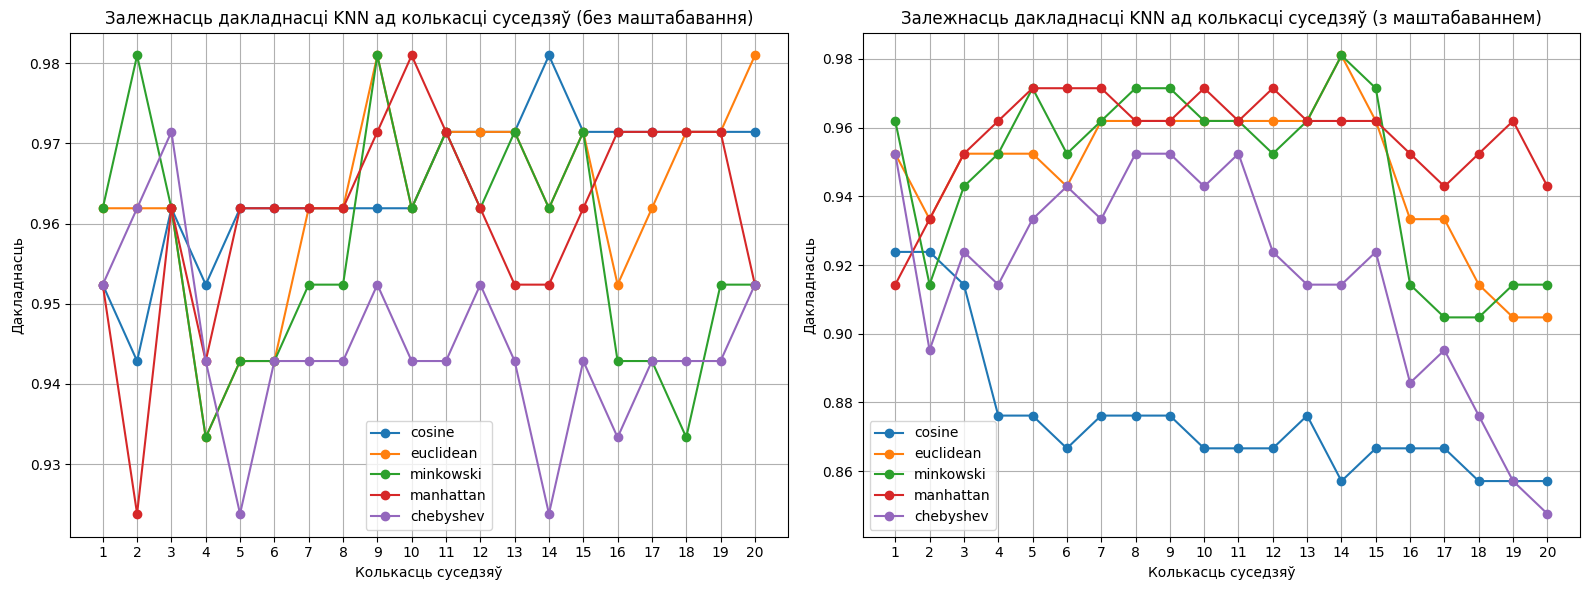

In [108]:
mtrcs = ["cosine", "euclidean", "minkowski", "manhattan", "chebyshev"]
rng = range(1, 21)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

best_acc = 0
best_params = None

for i in mtrcs:
    accuracies = []
    for j in rng:
        knn = KNeighborsClassifier(n_neighbors=j, weights='uniform', metric=i, p=3 if i=="minkowski" else 2)
        scores = cross_val_score(knn, X_train, y_train, cv=5)
        mean_score = scores.mean()
        accuracies.append(mean_score)
        if mean_score > best_acc:
            best_acc = mean_score
            best_params = (i, j)
    axes[0].plot(rng, accuracies, marker='o', label=f'{i}')

axes[0].set_title('Залежнасць дакладнасці KNN ад колькасці суседзяў (без маштабавання)')
axes[0].set_xlabel('Колькасць суседзяў')
axes[0].set_ylabel('Дакладнасць')
axes[0].set_xticks(rng)
axes[0].grid(True)
axes[0].legend()

knn_final = KNeighborsClassifier(n_neighbors=best_params[1], metric=best_params[0], p=3 if best_params[0]=="minkowski" else 2)
knn_final.fit(X_train, y_train)
test_acc = knn_final.score(X_test, y_test)
print(f"Лепшыя параметры без маштабавання: метрыка = {best_params[0]}, суседзяў = {best_params[1]}")
print(f"Сярэдняя дакладнасць на крос-валідацыі: {best_acc:.4f}")
print(f"Дакладнасць на тэсце: {test_acc:.4f}")

best_acc_scaled = 0
best_params_scaled = None

for i in mtrcs:
    accuracies = []
    for j in rng:
        knn = KNeighborsClassifier(n_neighbors=j, weights='uniform', metric=i, p=3 if i=="minkowski" else 2)
        scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
        mean_score = scores.mean()
        accuracies.append(mean_score)
        if mean_score > best_acc_scaled:
            best_acc_scaled = mean_score
            best_params_scaled = (i, j)
    axes[1].plot(rng, accuracies, marker='o', label=f'{i}')

axes[1].set_title('Залежнасць дакладнасці KNN ад колькасці суседзяў (з маштабаваннем)')
axes[1].set_xlabel('Колькасць суседзяў')
axes[1].set_ylabel('Дакладнасць')
axes[1].set_xticks(rng)
axes[1].grid(True)
axes[1].legend()

knn_final_scaled = KNeighborsClassifier(n_neighbors=best_params_scaled[1], metric=best_params_scaled[0], p=3 if best_params_scaled[0]=="minkowski" else 2)
knn_final_scaled.fit(X_train_scaled, y_train)
test_acc_scaled = knn_final_scaled.score(X_test_scaled, y_test)
print(f"Лепшыя параметры з маштабаваннем: метрыка = {best_params_scaled[0]}, суседзяў = {best_params_scaled[1]}")
print(f"Сярэдняя дакладнасць на крос-валідацыі: {best_acc_scaled:.4f}")
print(f"Дакладнасць на тэсце: {test_acc_scaled:.4f}")

plt.tight_layout()
plt.show()

# Вынікі

- На дадзенай выбарцы статыстыка лепшых параметраў наступная:
    - Без маштабавання: косінусная метрыка, 14 суседзяў
    - З маштабаваннем: Эўклідавая метрыка, 14 суседзяў
- Гэтая статыстыка адрозніваецца пры іншых раздзяленнях (пры змене random_state у train_state_split). <br>Напрыклад, пры random_state=100 вынікі наступныя:
    - Без маштабавання: мангэтанская метрыка, 13 суседзяў
    - З маштабаваннем: мангэтанская метрыка, 6 суседзяў
- На розных выбарках таксама адрозніваецца разбежка паміж сярэднімі рэзультатамі валідацыі й дакладнасцю на тэсце.

- Датасэт добра падыходзіць для KNN: усе класы раздзеленыя, звесткі збалансаваныя (па 50 на кожны клас), параметраў няшмат.

- Эфектыўнасць KNN абмежаваная невялікім размерам датасэта.